In [28]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub

# Download latest version
path = kagglehub.dataset_download("ipythonx/mvtec-ad")

print("Path to dataset files:", path)

/kaggle/input/datasets/ipythonx/mvtec-ad/readme.txt
/kaggle/input/datasets/ipythonx/mvtec-ad/license.txt
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/readme.txt
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/license.txt
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/000_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/003_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/004_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/005_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/001_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/006_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/008_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/007_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/002_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/009_mask.png
/kaggle/in

In [29]:
!pip install anomalib -q

In [30]:
import shutil, os

DATA_ROOT = "/kaggle/input/datasets/ipythonx/mvtec-ad"  # set to what Cell 2 printed
WORK_ROOT = "/kaggle/working/MVTecAD"

# Copy just one category to start — faster, and you only need 'bottle' for day one
category = "bottle"
src = os.path.join(DATA_ROOT, category)
dst = os.path.join(WORK_ROOT, category)
if not os.path.exists(dst):
    shutil.copytree(src, dst)
print("Ready at:", dst, "->", os.listdir(dst))

Ready at: /kaggle/working/MVTecAD/bottle -> ['ground_truth', 'readme.txt', 'train', 'test', 'license.txt']


In [31]:
import numpy as np
import cv2
import albumentations as A

# ---- Custom: directional shadow gradient (overhead lamp / passing occlusion) ----
class DirectionalShadow(A.ImageOnlyTransform):
    """Darkens the image along a random linear gradient, mimicking
    uneven overhead lighting or a shadow cast across the conveyor."""
    def __init__(self, min_factor=0.4, max_factor=0.85, p=0.5):
        super().__init__(p=p)
        self.min_factor = min_factor   # darkest multiplier at the shadowed edge
        self.max_factor = max_factor

    def apply(self, img, **kwargs):
        h, w = img.shape[:2]
        # random gradient direction
        angle = np.random.uniform(0, 2 * np.pi)
        xx, yy = np.meshgrid(np.linspace(0, 1, w), np.linspace(0, 1, h))
        grad = xx * np.cos(angle) + yy * np.sin(angle)
        grad = (grad - grad.min()) / (grad.max() - grad.min() + 1e-8)
        dark = np.random.uniform(self.min_factor, self.max_factor)
        mask = dark + (1 - dark) * grad            # ranges [dark, 1.0] across image
        out = img.astype(np.float32) * mask[..., None]
        return np.clip(out, 0, 255).astype(img.dtype)


# ---- The factory-lighting stress transform ----
# Ranges chosen to be NOTICEABLE but not destructive — a human should still
# easily see the bottle and any defect. If a person can't, the model shouldn't
# be blamed for failing, and the test is unfair.
factory_lighting = A.Compose([
    # Overall brightness/contrast drift — bulbs dimming, haze.
    A.RandomBrightnessContrast(
        brightness_limit=(-0.25, 0.25),   # ±25% — visible but not blown out
        contrast_limit=(-0.20, 0.20),     # ±20%
        p=0.9,
    ),
    # Non-linear exposure response (more realistic than linear brightness alone)
    A.RandomGamma(gamma_limit=(80, 120), p=0.7),   # 0.8x–1.2x gamma
    # Color temperature: warm/cool cast from different bulb types.
    # Mild — glass tint shifts, but you don't want to recolor the bottle entirely.
    A.HueSaturationValue(
        hue_shift_limit=8,                # small hue swing
        sat_shift_limit=15,
        val_shift_limit=10,
        p=0.6,
    ),
    # Directional shadow across the frame — the production-specific one.
    DirectionalShadow(min_factor=0.45, max_factor=0.85, p=0.5),
], additional_targets={})   # photometric-only: masks pass through unchanged

In [32]:
!pip install pytorch-msssim -q

In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import numpy as np
import cv2
from sklearn.metrics import roc_auc_score
from pytorch_msssim import ssim as ssim_fn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 256

In [34]:
import numpy as np
import cv2
import albumentations as A

# ---- Custom: directional shadow gradient (overhead lamp / passing occlusion) ----
class DirectionalShadow(A.ImageOnlyTransform):
    """Darkens the image along a random linear gradient, mimicking
    uneven overhead lighting or a shadow cast across the conveyor."""
    def __init__(self, min_factor=0.4, max_factor=0.85, p=0.5):
        super().__init__(p=p)
        self.min_factor = min_factor   # darkest multiplier at the shadowed edge
        self.max_factor = max_factor

    def apply(self, img, **kwargs):
        h, w = img.shape[:2]
        # random gradient direction
        angle = np.random.uniform(0, 2 * np.pi)
        xx, yy = np.meshgrid(np.linspace(0, 1, w), np.linspace(0, 1, h))
        grad = xx * np.cos(angle) + yy * np.sin(angle)
        grad = (grad - grad.min()) / (grad.max() - grad.min() + 1e-8)
        dark = np.random.uniform(self.min_factor, self.max_factor)
        mask = dark + (1 - dark) * grad            # ranges [dark, 1.0] across image
        out = img.astype(np.float32) * mask[..., None]
        return np.clip(out, 0, 255).astype(img.dtype)


# ---- The factory-lighting stress transform ----
# Ranges chosen to be NOTICEABLE but not destructive — a human should still
# easily see the bottle and any defect. If a person can't, the model shouldn't
# be blamed for failing, and the test is unfair.
factory_lighting = A.Compose([
    # Overall brightness/contrast drift — bulbs dimming, haze.
    A.RandomBrightnessContrast(
        brightness_limit=(-0.25, 0.25),   # ±25% — visible but not blown out
        contrast_limit=(-0.20, 0.20),     # ±20%
        p=0.9,
    ),
    # Non-linear exposure response (more realistic than linear brightness alone)
    A.RandomGamma(gamma_limit=(80, 120), p=0.7),   # 0.8x–1.2x gamma
    # Color temperature: warm/cool cast from different bulb types.
    # Mild — glass tint shifts, but you don't want to recolor the bottle entirely.
    A.HueSaturationValue(
        hue_shift_limit=8,                # small hue swing
        sat_shift_limit=15,
        val_shift_limit=10,
        p=0.6,
    ),
    # Directional shadow across the frame — the production-specific one.
    DirectionalShadow(min_factor=0.45, max_factor=0.85, p=0.5),
], additional_targets={})   # photometric-only: masks pass through unchanged

In [35]:
import shutil
from pathlib import Path

src_root = Path("/kaggle/working/MVTecAD/bottle")
dst_root = Path("/kaggle/working/MVTecAD_lighting/bottle")

for split_dir in (src_root / "test").iterdir():        # good, broken_large, ...
    for img_path in split_dir.glob("*.png"):
        img = cv2.imread(str(img_path))                # BGR uint8
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        aug = factory_lighting(image=img)["image"]
        aug = cv2.cvtColor(aug, cv2.COLOR_RGB2BGR)
        out_path = dst_root / "test" / split_dir.name / img_path.name
        out_path.parent.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(out_path), aug)

# Masks: copy unchanged (photometric aug doesn't move defect locations)
shutil.copytree(src_root / "ground_truth",
                dst_root / "ground_truth", dirs_exist_ok=True)
# Training set: for the robustness TEST, you typically leave train clean and
# only need test/ + ground_truth/. If Anomalib complains about a missing
# train/good, copy the clean one over so the loader is happy:
shutil.copytree(src_root / "train",
                dst_root / "train", dirs_exist_ok=True)

PosixPath('/kaggle/working/MVTecAD_lighting/bottle/train')

In [36]:
# ----------------------------------------------------------------------
# 1. MODEL  (the architecture from before)
# ----------------------------------------------------------------------
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_ch=64):
        super().__init__()
        def enc_block(i, o):
            return nn.Sequential(
                nn.Conv2d(i, o, 4, stride=2, padding=1),
                nn.BatchNorm2d(o), nn.ReLU(inplace=True))
        def dec_block(i, o, last=False):
            layers = [nn.ConvTranspose2d(i, o, 4, stride=2, padding=1)]
            layers += ([nn.Sigmoid()] if last
                       else [nn.BatchNorm2d(o), nn.ReLU(inplace=True)])
            return nn.Sequential(*layers)

        self.encoder = nn.Sequential(
            enc_block(3, 32),
            enc_block(32, 64),
            enc_block(64, 128),
            enc_block(128, 256),
            enc_block(256, latent_ch))
        self.decoder = nn.Sequential(
            dec_block(latent_ch, 256),
            dec_block(256, 128),
            dec_block(128, 64),
            dec_block(64, 32),
            dec_block(32, 3, last=True))

    def forward(self, x):
        return self.decoder(self.encoder(x))

In [37]:
# ----------------------------------------------------------------------
# 2. DATA
# ----------------------------------------------------------------------
def load_img(path):
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img.astype(np.float32) / 255.0          # [0,1], HWC

def load_mask(path):
    if path is None or not Path(path).exists():
        return np.zeros((IMG_SIZE, IMG_SIZE), np.float32)
    m = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    m = cv2.resize(m, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    return (m > 0).astype(np.float32)

class TrainGood(Dataset):
    """Normal images only — the model never sees a defect during training."""
    def __init__(self, root):
        self.paths = sorted((Path(root) / "train" / "good").glob("*.png"))
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = load_img(self.paths[i])
        return torch.from_numpy(img).permute(2,0,1)   # CHW

class TestSet(Dataset):
    """All test images + their ground-truth masks + image label."""
    def __init__(self, root):
        root = Path(root)
        self.items = []
        for sub in sorted((root / "test").iterdir()):
            defect = sub.name                          # 'good' or a defect type
            for p in sorted(sub.glob("*.png")):
                label = 0 if defect == "good" else 1
                if defect == "good":
                    mask = None
                else:
                    mask = root / "ground_truth" / defect / f"{p.stem}_mask.png"
                self.items.append((p, mask, label))
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        path, mask, label = self.items[i]
        img = torch.from_numpy(load_img(path)).permute(2,0,1)
        m   = torch.from_numpy(load_mask(mask))
        return img, m, label

In [38]:
# ----------------------------------------------------------------------
# 3. LOSS  (MSE + SSIM — the part that makes it work)
# ----------------------------------------------------------------------
def recon_loss(recon, target, alpha=0.5):
    mse = F.mse_loss(recon, target)
    s   = ssim_fn(recon, target, data_range=1.0, size_average=True)
    return alpha * mse + (1 - alpha) * (1 - s)

In [39]:
# ----------------------------------------------------------------------
# 4. TRAIN
# ----------------------------------------------------------------------
def train(root, epochs=80, bs=16, lr=2e-4):
    loader = DataLoader(TrainGood(root), batch_size=bs, shuffle=True, num_workers=2, drop_last=True)
    model = ConvAutoencoder().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    for ep in range(epochs):
        tot = 0.0
        for x in loader:
            x = x.to(DEVICE)
            noise = torch.randn_like(x) * 0.1
            recon = model(x + noise)
            loss = recon_loss(recon, x)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item()
        if (ep+1) % 10 == 0 or ep == 0:
            print(f"epoch {ep+1:3d}/{epochs}  loss {tot/len(loader):.4f}")
    return model

In [44]:
# ----------------------------------------------------------------------
# 5. ANOMALY MAP  (per-pixel SSIM-dissimilarity)
# ----------------------------------------------------------------------
from pytorch_msssim import SSIM

# build once, reuse
_ssim_module = SSIM(data_range=1.0, size_average=False, channel=3, win_size=11)

def anomaly_map(model, x, win=11):
    """Per-pixel anomaly map from local SSIM dissimilarity. Higher = more anomalous."""
    model.eval()
    with torch.no_grad():
        recon = model(x)
        # pytorch_msssim doesn't expose the spatial map directly, so compute
        # a local-SSIM map manually via the standard windowed formulation:
        amap = _local_ssim_dissimilarity(x, recon, win=win)   # B,H,W in [0,1]
    return amap.cpu().numpy()

def _local_ssim_dissimilarity(x, y, win=11, C1=0.01**2, C2=0.03**2):
    # convert to grayscale-ish by averaging channels for the structural map
    xg = x.mean(1, keepdim=True)
    yg = y.mean(1, keepdim=True)
    pad = win // 2
    mu_x = F.avg_pool2d(xg, win, 1, pad)
    mu_y = F.avg_pool2d(yg, win, 1, pad)
    mu_x2, mu_y2, mu_xy = mu_x*mu_x, mu_y*mu_y, mu_x*mu_y
    sig_x = F.avg_pool2d(xg*xg, win, 1, pad) - mu_x2
    sig_y = F.avg_pool2d(yg*yg, win, 1, pad) - mu_y2
    sig_xy = F.avg_pool2d(xg*yg, win, 1, pad) - mu_xy
    ssim_map = ((2*mu_xy + C1)*(2*sig_xy + C2)) / ((mu_x2 + mu_y2 + C1)*(sig_x + sig_y + C2))
    return (1 - ssim_map).clamp(0, 1).squeeze(1)   # dissimilarity, B,H,W

In [41]:
# ----------------------------------------------------------------------
# 6. EVALUATE  ->  image-AUROC and pixel-AUROC, PatchCore-comparable
# ----------------------------------------------------------------------
def evaluate(model, root, topk_frac=0.01):
    ds = TestSet(root)
    loader = DataLoader(ds, batch_size=8, shuffle=False, num_workers=2)
    all_pixel_scores, all_pixel_gt = [], []
    all_img_scores,   all_img_gt   = [], []
    for imgs, masks, labels in loader:
        imgs = imgs.to(DEVICE)
        amaps = anomaly_map(model, imgs)                      # B,H,W numpy
        masks = masks.numpy()                                 # B,H,W
        for amap, m, lab in zip(amaps, masks, labels.numpy()):
            all_pixel_scores.append(amap.ravel())
            all_pixel_gt.append(m.ravel())
            # image score = mean of the top-k% hottest pixels (robust vs. pure max)
            flat = np.sort(amap.ravel())[::-1]
            k = max(1, int(len(flat) * topk_frac))
            all_img_scores.append(flat[:k].mean())
            all_img_gt.append(int(lab))
    pixel_scores = np.concatenate(all_pixel_scores)
    pixel_gt     = np.concatenate(all_pixel_gt)
    pixel_auroc  = roc_auc_score(pixel_gt, pixel_scores)
    image_auroc  = roc_auc_score(all_img_gt, all_img_scores)
    return {"image_AUROC": image_auroc, "pixel_AUROC": pixel_auroc}

In [42]:
# ----------------------------------------------------------------------
# 7. RUN
# ----------------------------------------------------------------------
CLEAN_ROOT    = "/kaggle/working/MVTecAD/bottle"
LIGHTING_ROOT = "/kaggle/working/MVTecAD_lighting/bottle"

model = train(CLEAN_ROOT, epochs=80)

clean_res    = evaluate(model, CLEAN_ROOT)
lighting_res = evaluate(model, LIGHTING_ROOT)

print("\n--- Autoencoder prototype ---")
print("Clean:   ", clean_res)
print("Lighting:", lighting_res)
print("\n--- PatchCore baseline (for reference) ---")
print("Clean:    image_AUROC=1.000  pixel_AUROC=0.986")
print("Lighting: image_AUROC=0.947  pixel_AUROC=0.973")

epoch   1/80  loss 0.4361
epoch  10/80  loss 0.2509
epoch  20/80  loss 0.1075
epoch  30/80  loss 0.0857
epoch  40/80  loss 0.0765
epoch  50/80  loss 0.0712
epoch  60/80  loss 0.0673
epoch  70/80  loss 0.0639
epoch  80/80  loss 0.0612

--- Autoencoder prototype ---
Clean:    {'image_AUROC': np.float64(0.8738095238095238), 'pixel_AUROC': np.float64(0.7426076883980987)}
Lighting: {'image_AUROC': np.float64(0.5111111111111111), 'pixel_AUROC': np.float64(0.5555417653826908)}

--- PatchCore baseline (for reference) ---
Clean:    image_AUROC=1.000  pixel_AUROC=0.986
Lighting: image_AUROC=0.947  pixel_AUROC=0.973


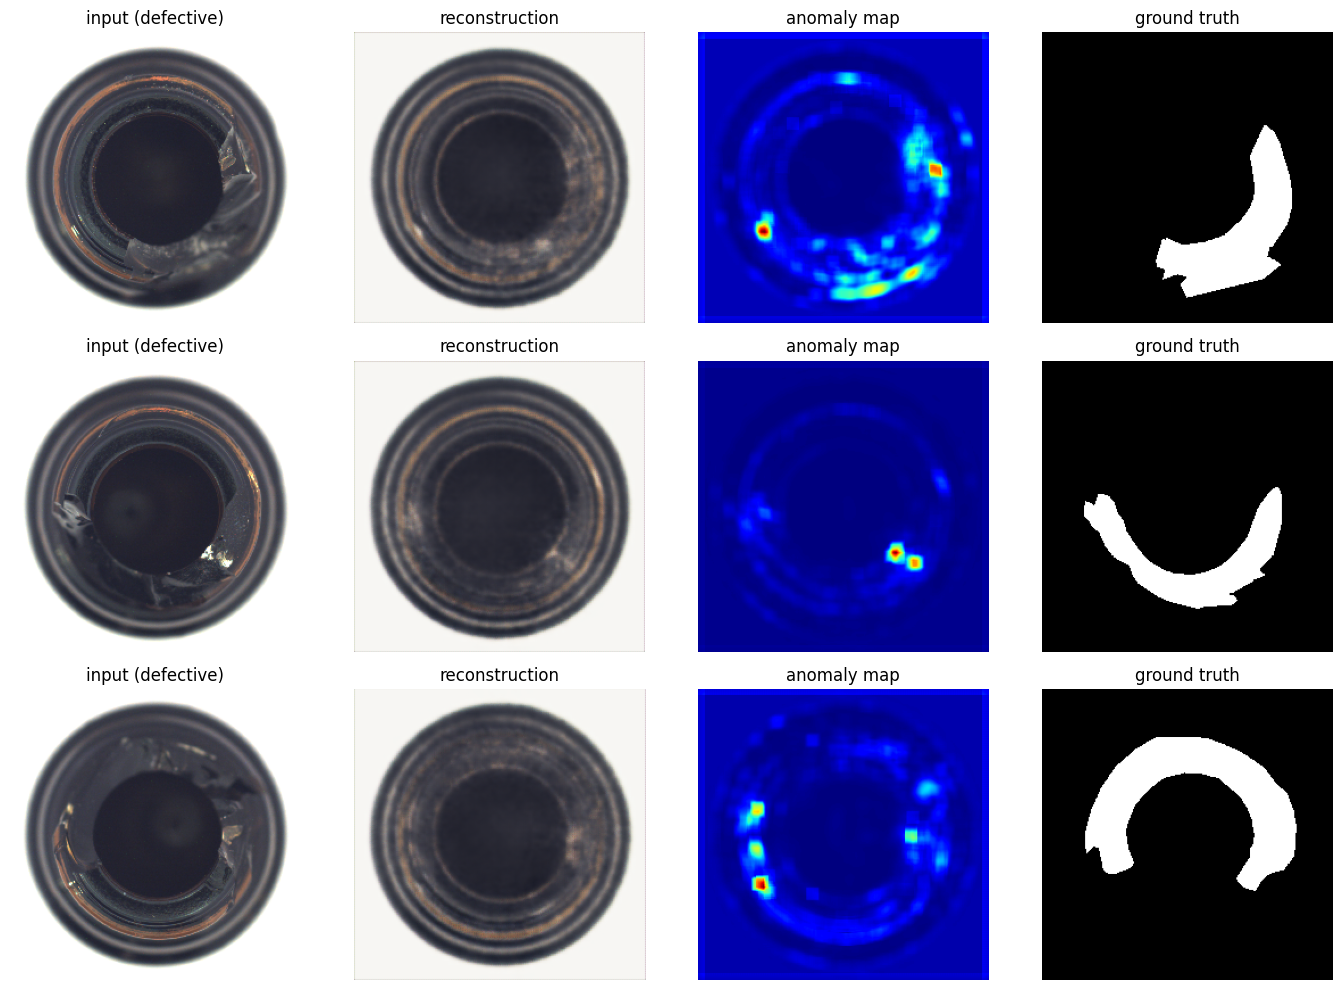

In [43]:
import matplotlib.pyplot as plt

ds = TestSet(CLEAN_ROOT)
model.eval()
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for row, idx in enumerate([i for i,(_,_,l) in enumerate(ds.items) if l==1][:3]):
    img, mask, _ = ds[idx]
    x = img.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        recon = model(x)
    amap = anomaly_map(model, x)[0]
    axes[row,0].imshow(img.permute(1,2,0));        axes[row,0].set_title("input (defective)")
    axes[row,1].imshow(recon[0].cpu().permute(1,2,0)); axes[row,1].set_title("reconstruction")
    axes[row,2].imshow(amap, cmap="jet");          axes[row,2].set_title("anomaly map")
    axes[row,3].imshow(mask, cmap="gray");         axes[row,3].set_title("ground truth")
for a in axes.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

In [45]:
clean_res    = evaluate(model, CLEAN_ROOT)
lighting_res = evaluate(model, LIGHTING_ROOT)

In [47]:
print("Clean:   ", clean_res)
print("Lighting:", lighting_res)

Clean:    {'image_AUROC': np.float64(0.9373015873015873), 'pixel_AUROC': np.float64(0.894248654987454)}
Lighting: {'image_AUROC': np.float64(0.5123015873015873), 'pixel_AUROC': np.float64(0.7149772983256325)}


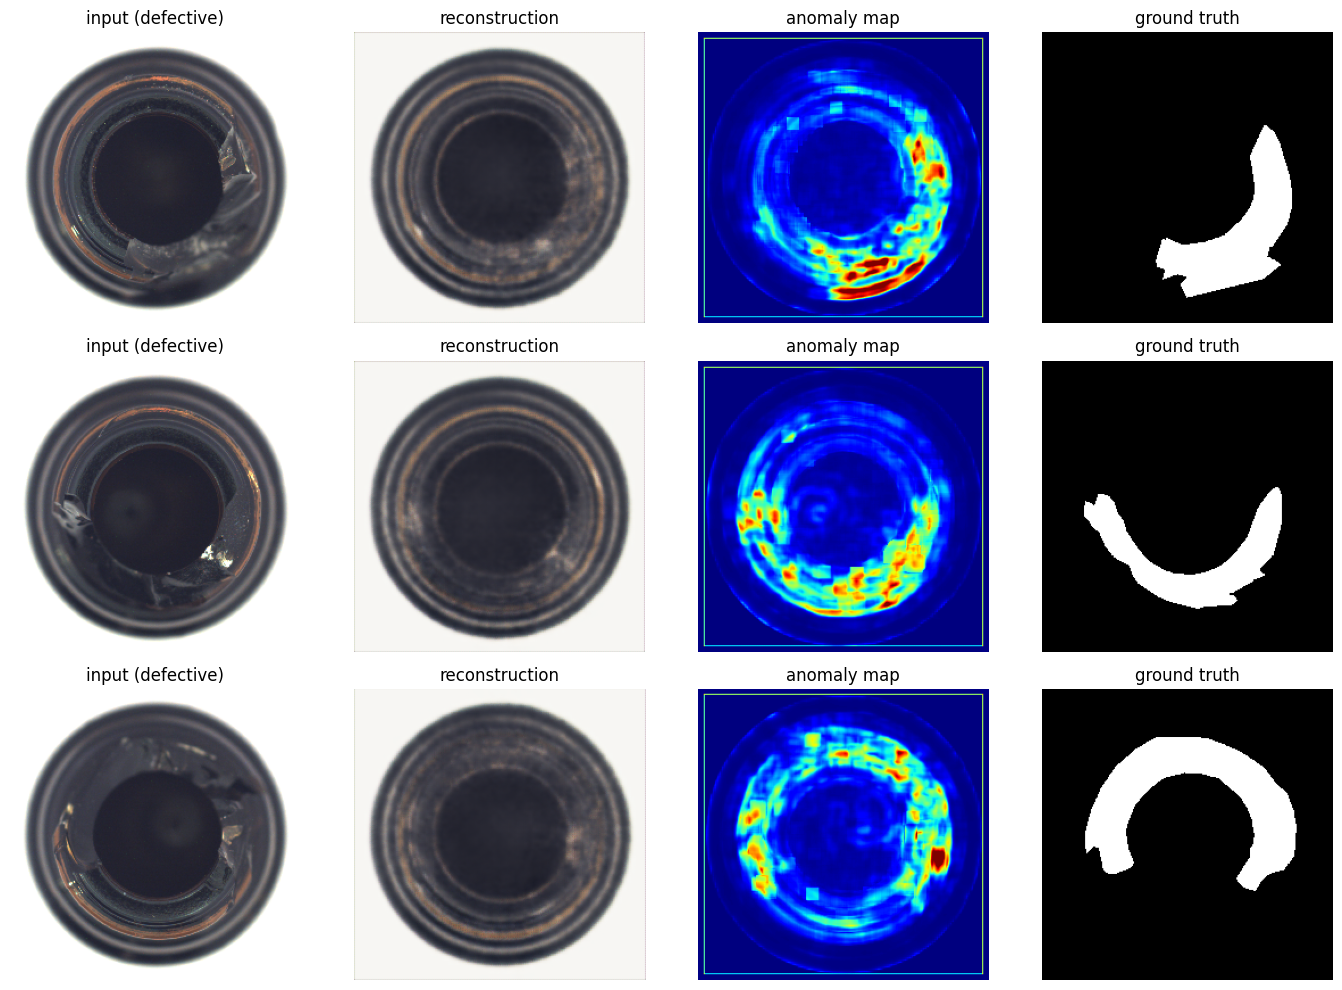

In [46]:
import matplotlib.pyplot as plt

ds = TestSet(CLEAN_ROOT)
model.eval()
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for row, idx in enumerate([i for i,(_,_,l) in enumerate(ds.items) if l==1][:3]):
    img, mask, _ = ds[idx]
    x = img.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        recon = model(x)
    amap = anomaly_map(model, x)[0]
    axes[row,0].imshow(img.permute(1,2,0));        axes[row,0].set_title("input (defective)")
    axes[row,1].imshow(recon[0].cpu().permute(1,2,0)); axes[row,1].set_title("reconstruction")
    axes[row,2].imshow(amap, cmap="jet");          axes[row,2].set_title("anomaly map")
    axes[row,3].imshow(mask, cmap="gray");         axes[row,3].set_title("ground truth")
for a in axes.ravel(): a.axis("off")
plt.tight_layout(); plt.show()